# Movie Sentiment Analysis

Dataset Link: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [3]:
import pandas as pd
import numpy as np

In [4]:
url_path = "IMDB Dataset.csv"
df_original = pd.read_csv(url_path)
df_original.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df = df_original.copy(deep=True)

# Basic info

In [6]:
print(df.columns.tolist())

['review', 'sentiment']


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [8]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [9]:
50000 - 49582 # no of duplicates

418

In [10]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

# Descriptive Stats

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# summary stats

df['review_char_length'] = df['review'].apply(len)
df['review_word_length'] = df['review'].apply(lambda x: len(x.split()))

# descriptive stats
print(df[['review_char_length', 'review_word_length']].describe())

       review_char_length  review_word_length
count        50000.000000        50000.000000
mean          1309.431020          231.156940
std            989.728014          171.343997
min             32.000000            4.000000
25%            699.000000          126.000000
50%            970.000000          173.000000
75%           1590.250000          280.000000
max          13704.000000         2470.000000


In [13]:
# Does too short or too long review has any relation to sentiment?

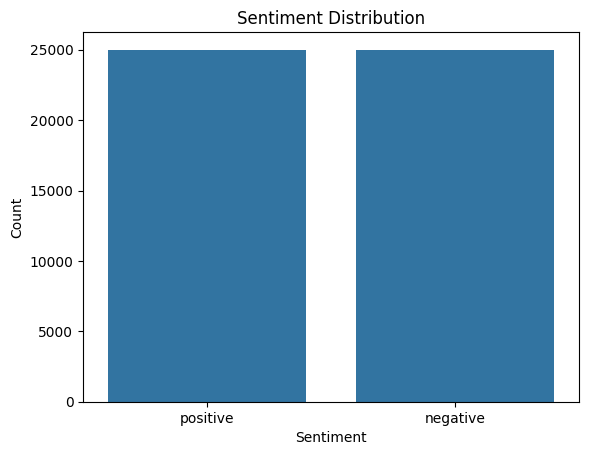

In [14]:
# sentiment distribution
sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Distribution') 
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

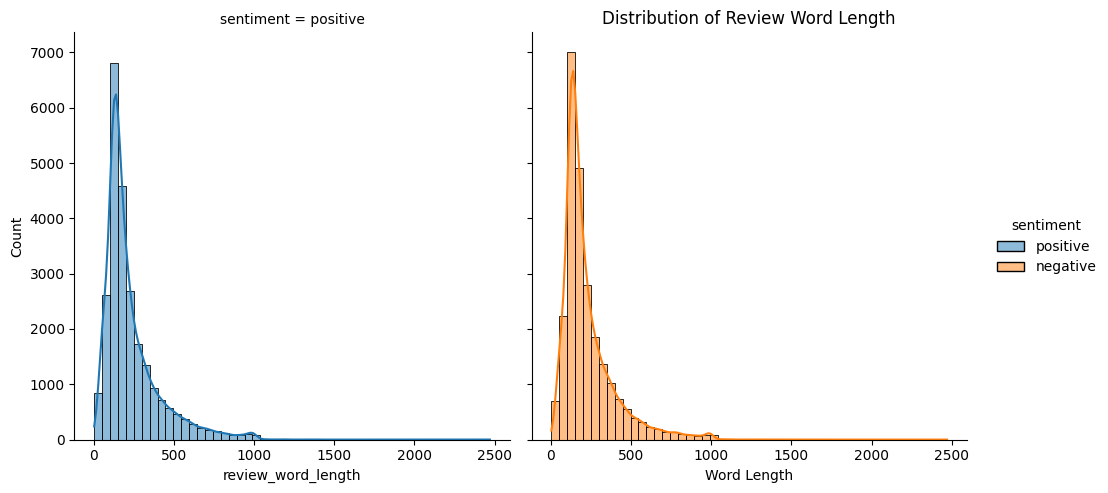

In [15]:
# Histogram of review word length
sns.displot(data=df, x='review_word_length', bins=50, col='sentiment', hue='sentiment',kde=True)
plt.title('Distribution of Review Word Length')
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.show()

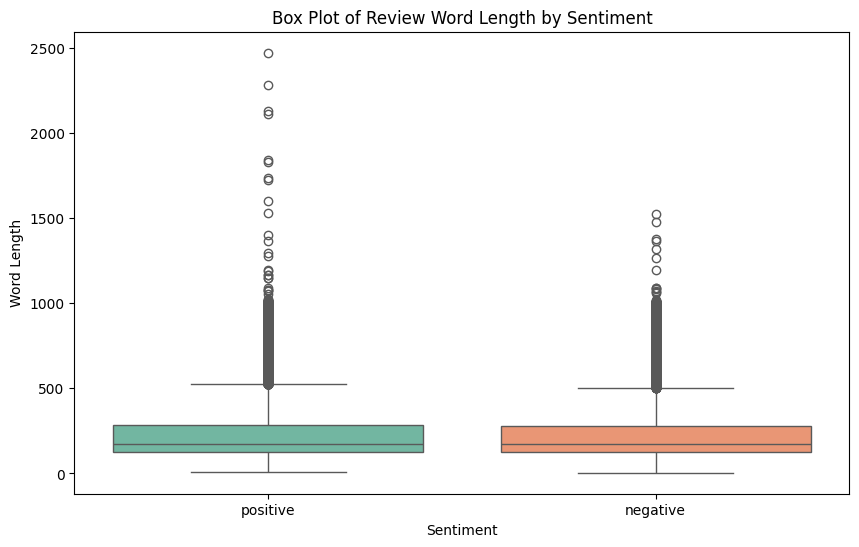

In [16]:
# Box plot of review word length by sentiment
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='review_word_length', data=df, palette='Set2', hue='sentiment')
plt.title('Box Plot of Review Word Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Word Length')
plt.show()

## Removing outliers

In [17]:
# Calculate Q1, Q2, Q3, IQR
q1 = df['review_word_length'].quantile(0.25)
q3 = df['review_word_length'].quantile(0.75)
iqr = q3 - q1

In [18]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

Lower Bound: -105.0, Upper Bound: 511.0


In [19]:
# df of outliers
outliers = df[(df['review_word_length'] < lower_bound) | (df['review_word_length'] > upper_bound)]
print(f"Number of outliers: {outliers.shape[0]}")

Number of outliers: 3708


In [20]:
# FE step
df_clean_from_iqr = df[(df['review_word_length'] >= lower_bound) & (df['review_word_length'] <= upper_bound)]
print("Original DataFrame shape:", df.shape[0])
print("Clean DataFrame shape:", df_clean_from_iqr.shape[0])

Original DataFrame shape: 50000
Clean DataFrame shape: 46292


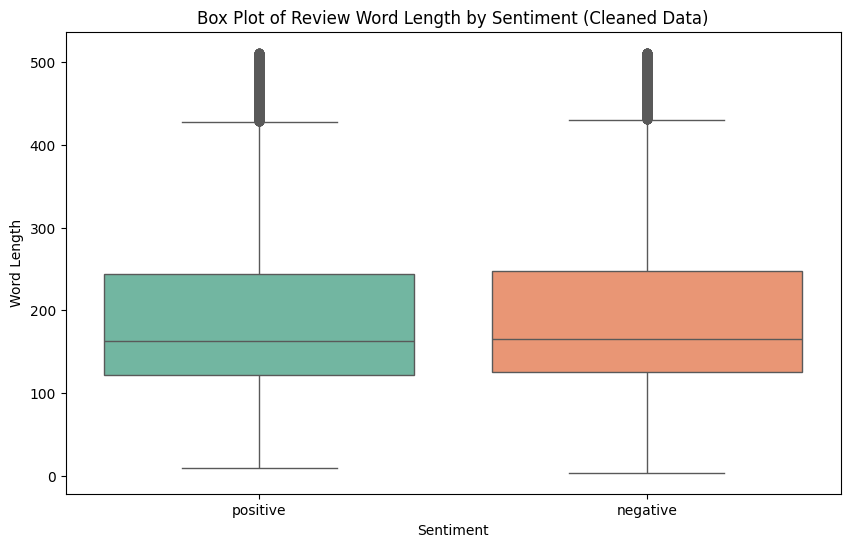

In [21]:
# Boxplot of review word length by sentiment
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='review_word_length', data=df_clean_from_iqr, palette='Set2', hue='sentiment')
plt.title('Box Plot of Review Word Length by Sentiment (Cleaned Data)')
plt.xlabel('Sentiment')
plt.ylabel('Word Length')
plt.show()

In [22]:
# how many positive words are in positive case -->
# # how many negative words are in negative case -->

## Most common words (Positive or Negative)

In [23]:
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

In [24]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\WINDOWS11\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [25]:
len(stop_words)

198

In [26]:
# remove symbols from the review (not alphabets)
def preprocess_text(text):
    # select only alphabet 
    words = re.findall(r'\b[a-z]+\b', text.lower())
    #print(words)
    return [w for w in words if w not in stop_words and w!="br"]



In [27]:
preprocess_text("<br > hello preeti how are you #123")

['hello', 'preeti']

In [28]:
preprocess_text("the movie was great")

['movie', 'great']

In [29]:
# Separate reviews by sentiment
pos_reviews = df[df['sentiment'] == 'positive']['review'].apply(preprocess_text)
neg_reviews = df[df['sentiment'] == 'negative']['review'].apply(preprocess_text)

In [30]:
print(type(pos_reviews))

<class 'pandas.Series'>


In [31]:
# flatten lists
pos_words = [word for review in pos_reviews for word in review]
neg_words = [word for review in neg_reviews for word in review]

In [32]:
# get some common values
pos_common = Counter(pos_words).most_common(30)
neg_common = Counter(neg_words).most_common(30)

In [33]:
print("Top 30 Positive Words:", pos_common)
print("Top 30 Negative Words:", neg_common)

Top 30 Positive Words: [('film', 42110), ('movie', 37854), ('one', 27320), ('like', 17714), ('good', 15025), ('great', 12964), ('story', 12934), ('time', 12752), ('well', 12729), ('see', 12276), ('also', 10793), ('really', 10739), ('would', 10595), ('even', 9617), ('first', 9230), ('much', 9201), ('people', 8719), ('love', 8692), ('best', 8510), ('get', 8285), ('life', 8137), ('way', 7865), ('many', 7627), ('films', 7601), ('made', 7351), ('think', 7208), ('two', 7161), ('characters', 7103), ('movies', 6996), ('character', 6925)]
Top 30 Negative Words: [('movie', 50117), ('film', 37595), ('one', 26283), ('like', 22458), ('even', 15254), ('good', 14728), ('bad', 14726), ('would', 14007), ('time', 12358), ('really', 12355), ('see', 10753), ('story', 10185), ('get', 10136), ('much', 10117), ('people', 9469), ('make', 9355), ('could', 9300), ('made', 8801), ('well', 8539), ('first', 8353), ('movies', 8313), ('plot', 8214), ('acting', 8087), ('way', 7780), ('characters', 7353), ('watch', 72

In [35]:
from sklearn.feature_extraction.text import CountVectorizer

In [36]:
""" CountVectorizer
(2,2) -> 2 .. 2 -> bigram
(3,3) -> 3 .. 3 -> trigram
(1,3) -> 1 2 3 -> unigram + bigram + trigram
(2,3) -> 2 3 -> bigram + trigram """

' CountVectorizer\n(2,2) -> 2 .. 2 -> bigram\n(3,3) -> 3 .. 3 -> trigram\n(1,3) -> 1 2 3 -> unigram + bigram + trigram\n(2,3) -> 2 3 -> bigram + trigram '

In [37]:
def get_top_ngrams(words_list, ngram_range=(2,2), top_n=20):
    vec = CountVectorizer(ngram_range=ngram_range)
    bag = vec.fit_transform([' '.join(words_list)])
    sum_words = bag.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    sorted_words = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return sorted_words[:top_n]

In [40]:
# Top bigrms
print("Top Positive Bigrams:", get_top_ngrams(pos_words,(2,2)))

Top Positive Bigrams: [('one best', np.int64(1680)), ('even though', np.int64(1099)), ('ever seen', np.int64(976)), ('first time', np.int64(960)), ('new york', np.int64(855)), ('special effects', np.int64(806)), ('see movie', np.int64(784)), ('must see', np.int64(778)), ('real life', np.int64(761)), ('years ago', np.int64(741)), ('good movie', np.int64(737)), ('well done', np.int64(727)), ('great movie', np.int64(703)), ('year old', np.int64(684)), ('sci fi', np.int64(623)), ('low budget', np.int64(594)), ('pretty good', np.int64(581)), ('watch movie', np.int64(578)), ('great film', np.int64(569)), ('saw movie', np.int64(567))]


In [41]:
# Top trigrams
print("Top Positive Trigrams:", get_top_ngrams(pos_words,(3,3)))
print("Top Negative Trigrams:", get_top_ngrams(neg_words,(3,3)))

Top Positive Trigrams: [('new york city', np.int64(195)), ('world war ii', np.int64(167)), ('one best movies', np.int64(144)), ('based true story', np.int64(135)), ('movie ever seen', np.int64(134)), ('one best films', np.int64(132)), ('first time saw', np.int64(115)), ('movies ever seen', np.int64(112)), ('films ever made', np.int64(99)), ('well worth watching', np.int64(95)), ('first saw movie', np.int64(94)), ('seen long time', np.int64(91)), ('highly recommend movie', np.int64(87)), ('international film festival', np.int64(83)), ('would love see', np.int64(81)), ('films ever seen', np.int64(77)), ('movies ever made', np.int64(75)), ('first saw film', np.int64(73)), ('many years ago', np.int64(73)), ('best movie ever', np.int64(72))]
Top Negative Trigrams: [('worst movie ever', np.int64(459)), ('movie ever seen', np.int64(394)), ('one worst movies', np.int64(311)), ('worst movies ever', np.int64(282)), ('movies ever seen', np.int64(268)), ('worst film ever', np.int64(202)), ('waste 

In [42]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\WINDOWS11\AppData\Roaming\nltk_data...


True

In [43]:
analyzer = SentimentIntensityAnalyzer()


In [44]:
def get_sentiment_score(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

In [45]:
get_sentiment_score("I love this movie! It's fantastic.")

'positive'

In [46]:
get_sentiment_score("how are you")

'neutral'

# Inferential Stats

In [48]:
# Goal 1: 
# Check if review len differs significantly between positive and negative reviews

# H0: Average review length(in words) is same for positive and negative review
# H1: Average review length(in words) is different for positive and negative review

from scipy.stats import ttest_ind

pos_lengths = df[df['sentiment'] == 'positive']['review_word_length']
neg_lengths = df[df['sentiment'] == 'negative']['review_word_length']

t_stat, p_value = ttest_ind(pos_lengths, neg_lengths, equal_var=False)

print(f"T-statistic: {t_stat}, P-value: {p_value}")
print("Mean words (positive reviews):", pos_lengths.mean())
print("Mean words (negative reviews):", neg_lengths.mean())

print("Median words (positive reviews):", pos_lengths.median())
print("Median words (negative reviews):", neg_lengths.median())

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in review lengths between positive and negative reviews.")
else:    
    print("Fail to reject the null hypothesis: There is no significant difference in review lengths between positive and negative reviews.")


T-statistic: 2.208670012690372, P-value: 0.027202144656625855
Mean words (positive reviews): 232.84932
Mean words (negative reviews): 229.46456
Median words (positive reviews): 172.0
Median words (negative reviews): 174.0
Reject the null hypothesis: There is a significant difference in review lengths between positive and negative reviews.
